In [1]:
# Cài đặt (hoặc cập nhật) PyTorch Geometric
!pip install --upgrade torch_geometric

# Cài đặt các thư viện phụ trợ (torch-sparse, pyg-lib, v.v.)
# Lệnh này sẽ tự động tìm phiên bản PyTorch và CUDA của bạn để cài đặt các gói tương thích
!pip install torch-scatter torch-sparse torch-cluster pyg-lib -f https://data.pyg.org/whl/torch-$(python -c 'import torch; print(torch.__version__)').html

Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html


Step 1: Loading Data for Explanation...
Step 2: Defining TGAT Model...
Step 3: Initializing Explainer...
Step 4: Running Explanation...
Explaining Target Node ID: 166967

Visualizing explanation for Node 166967...
Found 1 important edges.
Explanation saved to 'explanation_subgraph.png'


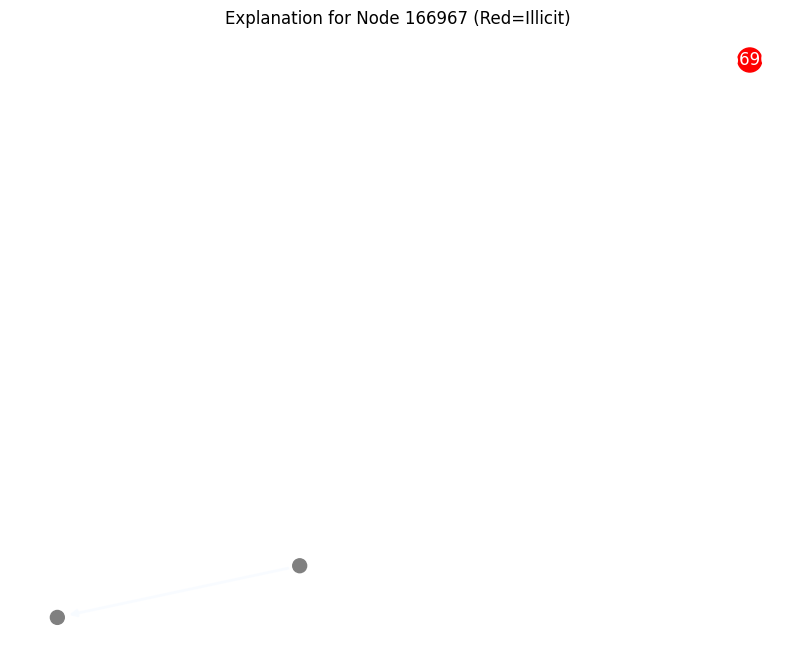

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.utils import k_hop_subgraph
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import softmax
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import networkx as nx
import warnings

warnings.filterwarnings("ignore")

# --- 1. Load & Prepare Data (Cần thiết để có object 'data' đúng định dạng) ---
print("Step 1: Loading Data for Explanation...")
try:
    df_features = pd.read_csv('/kaggle/input/elliptic/elliptic/elliptic_txs_features.csv', header=None)
    df_classes = pd.read_csv('/kaggle/input/elliptic/elliptic/elliptic_txs_classes.csv')
    df_edgelist = pd.read_csv('/kaggle/input/elliptic/elliptic/elliptic_txs_edgelist.csv')
except FileNotFoundError:
    print("Error: CSV files not found.")
    exit()

# Preprocessing
feature_cols = ['txId', 'timestep'] + [f'local_{i}' for i in range(93)] + [f'agg_{i}' for i in range(72)]
df_features.columns = feature_cols
all_tx_ids = df_features['txId'].unique()
tx_id_map = {tx_id: i for i, tx_id in enumerate(all_tx_ids)}

df_edgelist['txId1_idx'] = df_edgelist['txId1'].map(tx_id_map)
df_edgelist['txId2_idx'] = df_edgelist['txId2'].map(tx_id_map)

df_merged = pd.merge(df_features, df_classes, on='txId', how='left')
df_merged['class'] = df_merged['class'].map({'2': 0, '1': 1, 'unknown': np.nan})
df_merged = df_merged.set_index('txId').loc[all_tx_ids].reset_index()

features_no_time = [col for col in df_features.columns if col not in ['txId', 'timestep']]
X_df = df_merged[features_no_time]
y_series = df_merged['class']
timesteps = df_merged['timestep'].values

# Train/Test Split masks
test_mask_idx = X_df.index[(timesteps >= 42) & (y_series.notna())].values

scaler = StandardScaler()
# Fit on all data for simplicity in explanation demo (in rigorous training, fit on train only)
X_scaled = scaler.fit_transform(X_df)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Create Data Object with 'ts' attribute
data = Data(
    x=torch.tensor(X_scaled, dtype=torch.float),
    edge_index=torch.tensor(df_edgelist[['txId1_idx', 'txId2_idx']].values.T, dtype=torch.long),
    y=torch.tensor(y_series.values, dtype=torch.long),
    ts=torch.tensor(timesteps, dtype=torch.float) 
)
data = data.to(device)

# --- 2. Define Model Architecture (With Edge Mask Support) ---
print("Step 2: Defining TGAT Model...")

class TimeEncoder(nn.Module):
    def __init__(self, out_channels):
        super().__init__()
        self.w = nn.Linear(1, out_channels // 2) 
        self.p = nn.Linear(1, out_channels // 2)
    def forward(self, t):
        t = t.unsqueeze(-1)
        return torch.cat([torch.cos(self.w(t) + self.p(t)), torch.sin(self.w(t) + self.p(t))], dim=-1)

class TGATLayer(MessagePassing):
    def __init__(self, in_channels, out_channels, time_channels, heads=2, dropout=0.1):
        super().__init__(node_dim=0, aggr='add')
        self.heads = heads
        self.head_dim = out_channels // heads
        self.dropout = dropout
        
        total_in_dim = in_channels + time_channels
        self.lin_q = nn.Linear(total_in_dim, out_channels)
        self.lin_k = nn.Linear(total_in_dim, out_channels)
        self.lin_v = nn.Linear(total_in_dim, out_channels)
        self.lin_skip = nn.Linear(in_channels, out_channels)

    def forward(self, x, edge_index, t_emb, edge_mask=None):
        x_in = torch.cat([x, t_emb], dim=-1)
        q = self.lin_q(x_in).view(-1, self.heads, self.head_dim)
        k = self.lin_k(x_in).view(-1, self.heads, self.head_dim)
        v = self.lin_v(x_in).view(-1, self.heads, self.head_dim)

        out = self.propagate(edge_index, q=q, k=k, v=v, edge_mask=edge_mask, size=None)
        out = out.view(-1, self.heads * self.head_dim)
        out = out + self.lin_skip(x)
        return out

    def message(self, q_i, k_j, v_j, index, ptr, size_i, edge_mask):
        alpha = (q_i * k_j).sum(dim=-1) / np.sqrt(self.head_dim)
        alpha = softmax(alpha, index, ptr, size_i)
        
        # Apply Edge Mask if present
        if edge_mask is not None:
            alpha = alpha * edge_mask.unsqueeze(-1)
        
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)
        return v_j * alpha.unsqueeze(-1)

class TGATModel(nn.Module):
    def __init__(self, num_features, hidden_dim, num_classes, time_dim=32):
        super().__init__()
        self.time_enc = TimeEncoder(time_dim)
        self.conv1 = TGATLayer(num_features, hidden_dim, time_dim, heads=2)
        self.conv2 = TGATLayer(hidden_dim, hidden_dim, time_dim, heads=2)
        self.lin_out = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, edge_index, t, edge_mask=None):
        t_emb = self.time_enc(t)
        x = F.relu(self.conv1(x, edge_index, t_emb, edge_mask))
        x = F.relu(self.conv2(x, edge_index, t_emb, edge_mask))
        out = self.lin_out(x)
        return F.log_softmax(out, dim=1)

# Initialize and Load Weights
model = TGATModel(165, 128, 2).to(device)
try:
    # Load the BEST TGAT model we trained earlier
    model.load_state_dict(torch.load('best_tgat_model.pth'))
    print("Loaded pre-trained TGAT weights successfully.")
except FileNotFoundError:
    print("Warning: 'best_tgat_model.pth' not found. Initializing with random weights (Explanation will be random).")

model.eval()

# --- 3. Custom GNNExplainer (Fixed for numpy.int64) ---
print("Step 3: Initializing Explainer...")

class TGATExplainer:
    def __init__(self, model, data, device):
        self.model = model
        self.data = data
        self.device = device

    def explain_node(self, node_idx, epochs=200, lr=0.01):
        """
        Explains predictions for a specific node.
        """
        # --- FIX: Ép kiểu node_idx sang Tensor Long ---
        # Điều này giải quyết lỗi AttributeError: 'numpy.int64' object has no attribute 'to'
        if not isinstance(node_idx, torch.Tensor):
            node_idx = torch.tensor([node_idx], device=self.device, dtype=torch.long)
        # -----------------------------------------------
            
        # 1. Extract k-hop subgraph
        subset, sub_edge_index, mapping, edge_mask_hard = k_hop_subgraph(
            node_idx, num_hops=2, edge_index=self.data.edge_index, relabel_nodes=True
        )
        
        sub_x = self.data.x[subset].to(self.device)
        sub_t = self.data.ts[subset].to(self.device)
        sub_edge_index = sub_edge_index.to(self.device)
        target_idx_in_subgraph = mapping.item()

        # 2. Learnable Mask
        num_edges = sub_edge_index.shape[1]
        edge_mask = torch.nn.Parameter(torch.randn(num_edges, requires_grad=True, device=self.device))
        optimizer = torch.optim.Adam([edge_mask], lr=lr)

        # Get original prediction
        with torch.no_grad():
            original_logits = self.model(sub_x, sub_edge_index, sub_t)
            original_pred_class = original_logits[target_idx_in_subgraph].argmax().item()
            
        # 3. Optimization Loop
        self.model.eval()
        for epoch in range(epochs):
            optimizer.zero_grad()
            mask_sigmoid = torch.sigmoid(edge_mask)
            
            # Forward with mask
            logits = self.model(sub_x, sub_edge_index, sub_t, edge_mask=mask_sigmoid)
            pred_log_prob = logits[target_idx_in_subgraph]
            
            loss_pred = -pred_log_prob[original_pred_class]
            loss_reg = torch.mean(mask_sigmoid)
            loss = loss_pred + 0.05 * loss_reg 
            
            loss.backward()
            optimizer.step()
            
        return torch.sigmoid(edge_mask).detach().cpu().numpy(), subset, sub_edge_index

    def visualize_explanation(self, node_idx, edge_mask_scores, subset, sub_edge_index, threshold=0.5):
        # Đảm bảo node_idx là int chuẩn của Python để dùng với NetworkX
        if isinstance(node_idx, torch.Tensor):
            node_idx = node_idx.item()
        node_idx = int(node_idx)

        print(f"\nVisualizing explanation for Node {node_idx}...")
        
        # Chọn các cạnh quan trọng
        important_edge_indices = np.where(edge_mask_scores > threshold)[0]
        
        if len(important_edge_indices) == 0:
            print(f"No edges > {threshold}, showing top 10.")
            important_edge_indices = np.argsort(edge_mask_scores)[-10:]
            
        G = nx.DiGraph()
        
        # Add target node
        target_global = node_idx
        label_target = self.data.y[target_global].item()
        color_map = {0: 'blue', 1: 'red'} # 0: Licit, 1: Illicit
        
        G.add_node(target_global, color=color_map.get(label_target, 'gray'), size=300)
        
        subset_cpu = subset.cpu().numpy()
        sub_edge_index_cpu = sub_edge_index.cpu().numpy()
        
        print(f"Found {len(important_edge_indices)} important edges.")
        
        for idx in important_edge_indices:
            src_local = sub_edge_index_cpu[0, idx]
            dst_local = sub_edge_index_cpu[1, idx]
            
            src_global = int(subset_cpu[src_local])
            dst_global = int(subset_cpu[dst_local])
            
            label_src = self.data.y[src_global].item() if src_global < len(self.data.y) else -1
            
            G.add_node(src_global, color=color_map.get(label_src, 'gray'), size=100)
            
            weight = edge_mask_scores[idx]
            G.add_edge(src_global, dst_global, weight=weight)

        # Draw
        plt.figure(figsize=(10, 8))
        pos = nx.spring_layout(G, seed=42)
        
        # Handle empty graph case
        if G.number_of_nodes() > 0:
            node_colors = [nx.get_node_attributes(G, 'color').get(n, 'gray') for n in G.nodes()]
            node_sizes = [nx.get_node_attributes(G, 'size').get(n, 100) for n in G.nodes()]
            
            nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes)
            
            edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
            if edge_weights:
                nx.draw_networkx_edges(G, pos, width=2, edge_color=edge_weights, edge_cmap=plt.cm.Blues, alpha=0.8)
            
            labels = {n: str(n) if n == target_global else '' for n in G.nodes()}
            nx.draw_networkx_labels(G, pos, labels=labels, font_color='white')
            
            plt.title(f"Explanation for Node {target_global} (Red=Illicit)")
            plt.axis('off')
            plt.savefig('explanation_subgraph.png')
            print("Explanation saved to 'explanation_subgraph.png'")
            plt.show()
        else:
            print("Graph is empty, nothing to draw.")

# --- 4. Run Explainability ---
print("Step 4: Running Explanation...")

# Find a True Positive (Illicit predicted correctly as Illicit)
model.eval()
with torch.no_grad():
    # Get illicit nodes from Test set only
    illicit_nodes = np.where((y_series.values == 1) & (timesteps >= 42))[0]
    
    target_node = None
    # Check first 50 illicit nodes to find one correctly predicted
    for idx in illicit_nodes[:50]: 
        # FIX: Cast numpy.int64 to int for k_hop_subgraph
        node_idx_tensor = torch.tensor([int(idx)], device=device, dtype=torch.long)
        
        subset, sub_edge_index, mapping, _ = k_hop_subgraph(
            node_idx_tensor, num_hops=2, edge_index=data.edge_index, relabel_nodes=True
        )
        
        out = model(data.x[subset].to(device), sub_edge_index.to(device), data.ts[subset].to(device))
        pred = out[mapping].argmax().item()
        
        if pred == 1:
            target_node = int(idx)
            break

if target_node is None:
    print("Could not find a True Positive node. Using the first illicit node available.")
    target_node = int(illicit_nodes[0])

print(f"Explaining Target Node ID: {target_node}")

# Init Explainer
explainer = TGATExplainer(model, data, device)

# Train Mask
mask_scores, subset, sub_edge_index = explainer.explain_node(target_node)

# Visualize
explainer.visualize_explanation(target_node, mask_scores, subset, sub_edge_index, threshold=0.5)